In [ ]:
# ============================================================================
# MULTI-DATASET TRAINING: 9 CLASSES FROM 3 DATASETS
# Alzheimer (4) + Chest (2) + Lung (3) = 9 classes total


In [ ]:
# SETUP & INSTALLATION


In [1]:
# ============================================================================
# INSTALLATION & IMPORTS
# ============================================================================

!pip install -q timm torch torchvision tqdm scikit-learn

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import json
import pickle
from collections import defaultdict
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt
import time

print("✓ All packages imported successfully!")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")

Mounted at /content/drive
✓ All packages imported successfully!
✓ PyTorch version: 2.9.0+cu126
✓ CUDA available: True


In [ ]:
# CONFIGURATION - MULTI-DATASET


In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# 🔧 UPDATE THESE PATHS
CONFIG = {
    # Paths
    'feature_extractor_path': '/content/drive/MyDrive/FYP/datasets/output_dir/convnextv2_multi_512d.pt',
    'data_root': '/content/local_data',  # Will use local storage for speed
    'output_dir': '/content/drive/MyDrive/FYP/datasets/output_dir',

    # Dataset paths
    'dataset_paths': {
        'alzheimer': "/content/drive/MyDrive/FYP/datasets/Alzheimer's MRI",
        'chest': '/content/drive/MyDrive/FYP/datasets/Chest',
        'lung': '/content/drive/MyDrive/FYP/datasets/Lung'
    },

    # Model architecture
    'input_dim': 512,          # ConvNeXt-V2 output dimension
    'hash_bits': 256,          # Output binary code length

    # Training hyperparameters
    'batch_size': 256,         # Large batch for contrastive learning
    'num_epochs': 100,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,

    # Loss weights
    'lambda_contrastive': 1.0,  # Contrastive loss weight
    'lambda_quantization': 0.1, # Quantization loss weight
    'lambda_balance': 0.01,     # Bit balance regularization weight

    # Contrastive learning
    'margin': 2.0,             # Contrastive margin
    'temperature': 0.1,        # Temperature for similarity

    # Data loading
    'num_workers': 4,
    'image_size': 224,

    # Early stopping
    'patience': 15,

    # Evaluation
    'top_k': 100,              # For mAP calculation
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)

print("\n" + "="*70)
print("DEEP HASHING CONFIGURATION")
print("="*70)
print(f"Input dimension: {CONFIG['input_dim']}")
print(f"Hash code length: {CONFIG['hash_bits']} bits")
print(f"Batch size: {CONFIG['batch_size']}")
print(f"Learning rate: {CONFIG['learning_rate']}")
print(f"Output directory: {CONFIG['output_dir']}")
print("="*70)


DEEP HASHING CONFIGURATION
Input dimension: 512
Hash code length: 256 bits
Batch size: 256
Learning rate: 0.001
Output directory: /content/drive/MyDrive/FYP/datasets/output_dir


In [ ]:
# VERIFY DATASET PATHS


In [3]:
# ============================================================================
# DEEP HASHING MODULE
# ============================================================================

class StraightThroughEstimator(torch.autograd.Function):
    """
    Straight-Through Estimator for binary quantization.
    Forward: binary quantization via sign()
    Backward: pass gradient through unchanged
    """
    @staticmethod
    def forward(ctx, input):
        return torch.sign(input)

    @staticmethod
    def backward(ctx, grad_output):
        # Straight-through: gradient passes unchanged
        return grad_output


class DeepHashingHead(nn.Module):
    """
    Deep Hashing Head: 512-D features → 256-bit binary codes

    Architecture:
        Linear(512 → 256)
        LayerNorm
        Tanh
        Sign (with STE during training)
    """
    def __init__(self, input_dim=512, hash_bits=256):
        super().__init__()

        self.hash_layer = nn.Sequential(
            nn.Linear(input_dim, hash_bits),
            nn.LayerNorm(hash_bits),
            nn.Tanh()
        )

        self.hash_bits = hash_bits

        # Initialize weights for better convergence
        nn.init.xavier_uniform_(self.hash_layer[0].weight)
        nn.init.constant_(self.hash_layer[0].bias, 0)

    def forward(self, x, return_continuous=False):
        """
        Args:
            x: Input features [B, 512]
            return_continuous: If True, return tanh output before binarization

        Returns:
            Binary hash codes [B, 256] if not return_continuous
            Continuous hash codes [B, 256] if return_continuous
        """
        # Generate continuous hash codes in [-1, 1]
        h_continuous = self.hash_layer(x)

        if return_continuous:
            return h_continuous

        # Binarize: use STE during training, sign during inference
        if self.training:
            h_binary = StraightThroughEstimator.apply(h_continuous)
        else:
            h_binary = torch.sign(h_continuous)

        return h_binary

    def get_binary_codes(self, x):
        """
        Get {0, 1} binary codes for storage/retrieval

        Args:
            x: Input features [B, 512]

        Returns:
            Binary codes in {0, 1} [B, 256]
        """
        self.eval()
        with torch.no_grad():
            h = self.forward(x, return_continuous=False)
            # Convert from {-1, 1} to {0, 1}
            binary_codes = (h + 1) / 2
            return binary_codes.long()


print("✓ Deep Hashing Module defined")

✓ Deep Hashing Module defined


In [4]:
# ============================================================================
# LOSS FUNCTIONS
# ============================================================================

class DeepHashingLoss(nn.Module):
    """
    Combined loss for deep hashing:
    1. Pairwise Contrastive Loss (similar vs dissimilar pairs)
    2. Quantization Loss (minimize ||h| - 1|)
    3. Bit Balance Regularization (encourage balanced bits)
    """
    def __init__(self, margin=2.0, lambda_quant=0.1, lambda_balance=0.01):
        super().__init__()
        self.margin = margin
        self.lambda_quant = lambda_quant
        self.lambda_balance = lambda_balance

    def contrastive_loss(self, h1, h2, labels1, labels2):
        """
        Pairwise contrastive loss based on label similarity

        Args:
            h1, h2: Hash codes [B, K]
            labels1, labels2: Class labels [B]

        Returns:
            Contrastive loss scalar
        """
        # Determine if pairs are similar (same class)
        similar = (labels1.unsqueeze(1) == labels2.unsqueeze(0)).float()

        # Hamming distance in continuous space (before binarization)
        # Distance = 0.5 * (K - h1 @ h2^T)
        dist = 0.5 * (h1.shape[1] - h1 @ h2.T)

        # Contrastive loss:
        # - Similar pairs: minimize distance
        # - Dissimilar pairs: maximize distance up to margin
        loss_similar = similar * dist
        loss_dissimilar = (1 - similar) * F.relu(self.margin - dist)

        loss = (loss_similar + loss_dissimilar).mean()

        return loss

    def quantization_loss(self, h_continuous):
        """
        Quantization loss: minimize ||h| - 1|
        Encourages hash codes to be close to {-1, +1}

        Args:
            h_continuous: Continuous hash codes [B, K]

        Returns:
            Quantization loss scalar
        """
        # Mean absolute deviation from {-1, 1}
        loss = torch.mean(torch.abs(torch.abs(h_continuous) - 1))
        return loss

    def balance_loss(self, h_continuous):
        """
        Bit balance regularization: encourage each bit to be 50% -1 and 50% +1

        Args:
            h_continuous: Continuous hash codes [B, K]

        Returns:
            Balance loss scalar
        """
        # Mean across batch for each bit should be close to 0
        bit_means = torch.mean(h_continuous, dim=0)
        loss = torch.mean(bit_means ** 2)
        return loss

    def forward(self, h1_continuous, h2_continuous, labels1, labels2):
        """
        Compute total loss

        Args:
            h1_continuous, h2_continuous: Continuous hash codes [B, K]
            labels1, labels2: Class labels [B]

        Returns:
            Total loss and individual loss components (dict)
        """
        # 1. Contrastive loss
        loss_contrastive = self.contrastive_loss(h1_continuous, h2_continuous, labels1, labels2)

        # 2. Quantization loss
        h_all = torch.cat([h1_continuous, h2_continuous], dim=0)
        loss_quant = self.quantization_loss(h_all)

        # 3. Balance loss
        loss_balance = self.balance_loss(h_all)

        # Total loss
        total_loss = (
            loss_contrastive +
            self.lambda_quant * loss_quant +
            self.lambda_balance * loss_balance
        )

        losses = {
            'total': total_loss,
            'contrastive': loss_contrastive,
            'quantization': loss_quant,
            'balance': loss_balance
        }

        return total_loss, losses


print("✓ Loss functions defined")

✓ Loss functions defined


In [ ]:
# CUSTOM DATASET CLASS


In [5]:
# ============================================================================
# DATASET FOR FEATURE EXTRACTION
# ============================================================================

class MedicalImageDataset(Dataset):
    """
    Dataset that loads medical images from multiple datasets
    """
    def __init__(self, data_paths, transform=None):
        self.transform = transform
        self.samples = []

        # Load all image paths and labels
        for dataset_name, root_path in data_paths.items():
            if not os.path.exists(root_path):
                print(f"⚠️ Skipping {dataset_name}: path not found")
                continue

            classes = sorted([d for d in os.listdir(root_path)
                            if os.path.isdir(os.path.join(root_path, d))])

            class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

            for cls in classes:
                class_path = os.path.join(root_path, cls)
                class_id = class_to_idx[cls]

                for img_name in os.listdir(class_path):
                    # Skip hidden files
                    if img_name.startswith('.'):
                        continue

                    if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                        img_path = os.path.join(class_path, img_name)
                        # Store global label (dataset_name + class_id)
                        global_label = f"{dataset_name}_{class_id}"
                        self.samples.append((img_path, global_label, dataset_name))

        # Create label to index mapping
        unique_labels = sorted(set(label for _, label, _ in self.samples))
        self.label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
        self.idx_to_label = {idx: label for label, idx in self.label_to_idx.items()}

        print(f"\n✓ Loaded {len(self.samples)} images")
        print(f"✓ Number of classes: {len(unique_labels)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label_str, dataset_name = self.samples[idx]
        label_idx = self.label_to_idx[label_str]

        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label_idx
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return black image on error
            if self.transform:
                return self.transform(Image.new('RGB', (224, 224))), label_idx
            return Image.new('RGB', (224, 224)), label_idx


print("✓ Dataset class defined")

✓ Dataset class defined


In [ ]:
# DATA AUGMENTATION & LOADING


In [6]:
# ============================================================================
# FEATURE EXTRACTION
# ============================================================================

def extract_features(feature_extractor, dataloader, device):
    """
    Extract 512-D features from all images using pre-trained ConvNeXt-V2

    Args:
        feature_extractor: Pre-trained model
        dataloader: DataLoader for images
        device: torch device

    Returns:
        features: numpy array [N, 512]
        labels: numpy array [N]
    """
    feature_extractor.eval()

    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Extracting features'):
            images = images.to(device)

            # Extract features (512-D)
            features = feature_extractor(images, return_features=True)

            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())

    features = np.concatenate(all_features, axis=0)
    labels = np.concatenate(all_labels, axis=0)

    return features, labels


print("✓ Feature extraction function defined")

✓ Feature extraction function defined


In [7]:
# ============================================================================
# LOAD PRE-TRAINED FEATURE EXTRACTOR
# ============================================================================

print("\n" + "="*70)
print("LOADING PRE-TRAINED FEATURE EXTRACTOR")
print("="*70)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n✓ Using device: {device}")

if device.type == 'cpu':
    print("⚠️ WARNING: Training on CPU will be VERY slow!")
    print("   Expected time: 3-5 hours instead of 20-30 minutes on GPU")
    print("   Consider enabling GPU: Runtime → Change runtime type → T4 GPU")

# Define model class (required for loading saved models)
class ConvNeXtV2FeatureExtractor(nn.Module):
    """ConvNeXt-v2 with 512-D L2-normalized features"""

    def __init__(self, model_size='tiny', num_classes=9, feature_dim=512):
        super().__init__()

        model_name = f'convnextv2_{model_size}.fcmae_ft_in22k_in1k'
        self.backbone = timm.create_model(model_name, pretrained=False, num_classes=0)

        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224)
            backbone_dim = self.backbone(dummy_input).shape[1]

        self.projection = nn.Sequential(
            nn.Linear(backbone_dim, feature_dim),
            nn.LayerNorm(feature_dim),
            nn.GELU()
        )

        self.classifier = nn.Linear(feature_dim, num_classes)
        self.feature_dim = feature_dim
        self.num_classes = num_classes

    def forward(self, x, return_features=False):
        x = self.backbone(x)
        features = self.projection(x)
        features = nn.functional.normalize(features, p=2, dim=1)

        if return_features:
            return features

        logits = self.classifier(features)
        return logits

# Load feature extractor (with weights_only=False for PyTorch 2.6+)
print("\n📦 Loading checkpoint...")
checkpoint = torch.load(
    CONFIG['feature_extractor_path'],
    map_location=device,
    weights_only=False
)

feature_extractor = checkpoint['model']
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

# Freeze feature extractor
for param in feature_extractor.parameters():
    param.requires_grad = False

print(f"\n✓ Loaded feature extractor from:")
print(f"  {CONFIG['feature_extractor_path']}")
print(f"✓ Model architecture: ConvNeXt-V2-{checkpoint['config']['model_size']}")
print(f"✓ Feature dimension: {CONFIG['input_dim']}")
print(f"✓ Number of classes: {checkpoint['config']['num_classes']}")
print(f"✓ Best validation accuracy: {checkpoint.get('best_val_acc', 'N/A')}")
print(f"✓ All parameters frozen (not trainable)")

# Count parameters
total_params = sum(p.numel() for p in feature_extractor.parameters())
print(f"✓ Total parameters: {total_params:,}")

# Test feature extraction
print("\n🧪 Testing feature extraction...")
with torch.no_grad():
    test_input = torch.randn(2, 3, 224, 224).to(device)
    test_features = feature_extractor(test_input, return_features=True)

    print(f"✓ Test extraction successful:")
    print(f"  Input shape: {test_input.shape}")
    print(f"  Output shape: {test_features.shape}")
    print(f"  Feature range: [{test_features.min():.3f}, {test_features.max():.3f}]")
    print(f"  Feature dtype: {test_features.dtype}")

    # Check L2 normalization
    norms = torch.norm(test_features, p=2, dim=1)
    print(f"  L2 norms: {norms.tolist()}")
    print(f"  L2-normalized: {torch.allclose(norms, torch.ones_like(norms), atol=1e-6)}")

print("\n" + "="*70)
print("✅ FEATURE EXTRACTOR READY FOR FEATURE EXTRACTION")
print("="*70)



LOADING PRE-TRAINED FEATURE EXTRACTOR

✓ Using device: cuda

📦 Loading checkpoint...

✓ Loaded feature extractor from:
  /content/drive/MyDrive/FYP/datasets/output_dir/convnextv2_multi_512d.pt
✓ Model architecture: ConvNeXt-V2-tiny
✓ Feature dimension: 512
✓ Number of classes: 9
✓ Best validation accuracy: 0.9883658008658008
✓ All parameters frozen (not trainable)
✓ Total parameters: 28,265,865

🧪 Testing feature extraction...
✓ Test extraction successful:
  Input shape: torch.Size([2, 3, 224, 224])
  Output shape: torch.Size([2, 512])
  Feature range: [-0.071, 0.080]
  Feature dtype: torch.float32
  L2 norms: [1.0, 1.0]
  L2-normalized: True

✅ FEATURE EXTRACTOR READY FOR FEATURE EXTRACTION


In [8]:
# ============================================================================
# PREPARE DATASET
# ============================================================================

print("\n" + "="*70)
print("PREPARING DATASET")
print("="*70)

# Data transforms (same as feature extractor training)
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Create dataset
dataset = MedicalImageDataset(
    data_paths=CONFIG['dataset_paths'],
    transform=transform
)

# Create dataloader
dataloader = DataLoader(
    dataset,
    batch_size=64,  # For feature extraction
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print(f"\n✓ Dataset ready")
print(f"  Total images: {len(dataset)}")
print(f"  Total classes: {len(dataset.label_to_idx)}")
print(f"  Batches: {len(dataloader)}")
print("="*70)


PREPARING DATASET

✓ Loaded 18669 images
✓ Number of classes: 10

✓ Dataset ready
  Total images: 18669
  Total classes: 10
  Batches: 292


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [9]:
# ============================================================================
# EXTRACT FEATURES FROM ALL IMAGES
# ============================================================================

print("\n" + "="*70)
print("EXTRACTING FEATURES FROM ALL IMAGES")
print("This may take 5-10 minutes for 24k images...")
print("="*70)

start_time = time.time()

# Extract all features
features, labels = extract_features(feature_extractor, dataloader, device)

elapsed = time.time() - start_time

print(f"\n✓ Feature extraction complete!")
print(f"  Time: {elapsed/60:.2f} minutes")
print(f"  Features shape: {features.shape}")
print(f"  Labels shape: {labels.shape}")
print(f"  Feature range: [{features.min():.3f}, {features.max():.3f}]")
print(f"  Memory usage: {features.nbytes / 1024**2:.2f} MB")

# Save features for later use
features_cache_path = os.path.join(CONFIG['output_dir'], 'extracted_features.npz')
np.savez_compressed(features_cache_path, features=features, labels=labels)
print(f"\n✓ Features cached to: {features_cache_path}")

print("="*70)


EXTRACTING FEATURES FROM ALL IMAGES
This may take 5-10 minutes for 24k images...


Extracting features: 100%|██████████| 292/292 [17:01<00:00,  3.50s/it]



✓ Feature extraction complete!
  Time: 17.02 minutes
  Features shape: (18669, 512)
  Labels shape: (18669,)
  Feature range: [-0.109, 0.166]
  Memory usage: 36.46 MB

✓ Features cached to: /content/drive/MyDrive/FYP/datasets/output_dir/extracted_features.npz


In [10]:
# ============================================================================
# FEATURE DATASET (for Deep Hashing training)
# ============================================================================

class FeatureDataset(Dataset):
    """
    Dataset of pre-extracted features for Deep Hashing training
    """
    def __init__(self, features, labels):
        self.features = torch.from_numpy(features).float()
        self.labels = torch.from_numpy(labels).long()

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


# Create feature dataset
feature_dataset = FeatureDataset(features, labels)

# Split into train/val
train_size = int(0.8 * len(feature_dataset))
val_size = len(feature_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    feature_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"\n✓ Feature dataloaders created")
print(f"  Train samples: {len(train_dataset)}")
print(f"  Val samples: {len(val_dataset)}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")


✓ Feature dataloaders created
  Train samples: 14935
  Val samples: 3734
  Train batches: 58
  Val batches: 15


In [11]:
# ============================================================================
# INITIALIZE DEEP HASHING MODEL
# ============================================================================

print("\n" + "="*70)
print("INITIALIZING DEEP HASHING MODEL")
print("="*70)

# Create model
hash_model = DeepHashingHead(
    input_dim=CONFIG['input_dim'],
    hash_bits=CONFIG['hash_bits']
).to(device)

# Create loss function
criterion = DeepHashingLoss(
    margin=CONFIG['margin'],
    lambda_quant=CONFIG['lambda_quantization'],
    lambda_balance=CONFIG['lambda_balance']
)

# Create optimizer
optimizer = torch.optim.Adam(
    hash_model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG['num_epochs'],
    eta_min=1e-6
)

print(f"\n✓ Deep Hashing Model:")
print(f"  Input: {CONFIG['input_dim']}-D features")
print(f"  Output: {CONFIG['hash_bits']}-bit binary codes")
print(f"  Parameters: {sum(p.numel() for p in hash_model.parameters()):,}")
print(f"  Trainable: {sum(p.numel() for p in hash_model.parameters() if p.requires_grad):,}")
print(f"\n✓ Training setup:")
print(f"  Optimizer: Adam")
print(f"  Learning rate: {CONFIG['learning_rate']}")
print(f"  Batch size: {CONFIG['batch_size']}")
print(f"  Epochs: {CONFIG['num_epochs']}")
print("="*70)


INITIALIZING DEEP HASHING MODEL

✓ Deep Hashing Model:
  Input: 512-D features
  Output: 256-bit binary codes
  Parameters: 131,840
  Trainable: 131,840

✓ Training setup:
  Optimizer: Adam
  Learning rate: 0.001
  Batch size: 256
  Epochs: 100


In [12]:
# ============================================================================
# TRAINING FUNCTIONS
# ============================================================================

def train_epoch(model, loader, criterion, optimizer, device):
    """
    Train for one epoch
    """
    model.train()

    total_loss = 0.0
    loss_components = defaultdict(float)

    pbar = tqdm(loader, desc='Training', ncols=120)
    for features, labels in pbar:
        features = features.to(device)
        labels = labels.to(device)

        # Split batch in half for pair generation
        mid = features.size(0) // 2
        features1, labels1 = features[:mid], labels[:mid]
        features2, labels2 = features[mid:2*mid], labels[mid:2*mid]

        optimizer.zero_grad()

        # Generate continuous hash codes
        h1_continuous = model(features1, return_continuous=True)
        h2_continuous = model(features2, return_continuous=True)

        # Compute loss
        loss, losses = criterion(h1_continuous, h2_continuous, labels1, labels2)

        # Backward
        loss.backward()
        optimizer.step()

        # Track metrics
        total_loss += loss.item()
        for key, val in losses.items():
            loss_components[key] += val.item()

        pbar.set_postfix({
            'loss': f"{total_loss/(pbar.n+1):.4f}",
            'cont': f"{loss_components['contrastive']/(pbar.n+1):.4f}",
            'quant': f"{loss_components['quantization']/(pbar.n+1):.4f}"
        })

    # Average losses
    avg_loss = total_loss / len(loader)
    avg_components = {k: v / len(loader) for k, v in loss_components.items()}

    return avg_loss, avg_components


def validate(model, loader, criterion, device):
    """
    Validate the model
    """
    model.eval()

    total_loss = 0.0
    loss_components = defaultdict(float)

    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation', ncols=120)
        for features, labels in pbar:
            features = features.to(device)
            labels = labels.to(device)

            # Split batch
            mid = features.size(0) // 2
            features1, labels1 = features[:mid], labels[:mid]
            features2, labels2 = features[mid:2*mid], labels[mid:2*mid]

            # Generate hash codes
            h1_continuous = model(features1, return_continuous=True)
            h2_continuous = model(features2, return_continuous=True)

            # Compute loss
            loss, losses = criterion(h1_continuous, h2_continuous, labels1, labels2)

            total_loss += loss.item()
            for key, val in losses.items():
                loss_components[key] += val.item()

            pbar.set_postfix({'loss': f"{total_loss/(pbar.n+1):.4f}"})

    avg_loss = total_loss / len(loader)
    avg_components = {k: v / len(loader) for k, v in loss_components.items()}

    return avg_loss, avg_components


print("✓ Training functions defined")

✓ Training functions defined


In [13]:
# ============================================================================
# TRAINING LOOP
# ============================================================================

print("\n" + "="*70)
print("STARTING DEEP HASHING TRAINING")
print("="*70)

best_val_loss = float('inf')
patience_counter = 0
history = {
    'train_loss': [],
    'val_loss': [],
    'train_contrastive': [],
    'train_quantization': [],
    'train_balance': []
}

start_time = time.time()

for epoch in range(CONFIG['num_epochs']):
    print(f"\nEpoch {epoch+1}/{CONFIG['num_epochs']}")
    print("-" * 70)

    # Train
    train_loss, train_components = train_epoch(
        hash_model, train_loader, criterion, optimizer, device
    )

    # Validate
    val_loss, val_components = validate(
        hash_model, val_loader, criterion, device
    )

    # Update scheduler
    scheduler.step()

    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_contrastive'].append(train_components['contrastive'])
    history['train_quantization'].append(train_components['quantization'])
    history['train_balance'].append(train_components['balance'])

    # Print metrics
    print(f"\nTrain Loss: {train_loss:.4f}")
    print(f"  - Contrastive: {train_components['contrastive']:.4f}")
    print(f"  - Quantization: {train_components['quantization']:.4f}")
    print(f"  - Balance: {train_components['balance']:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        # Save checkpoint
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': hash_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'config': CONFIG,
            'history': history
        }, os.path.join(CONFIG['output_dir'], 'best_deephash_model.pt'))

        print(f"✓ Best model saved! (Val Loss: {val_loss:.4f})")
    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= CONFIG['patience']:
        print(f"\n⏹ Early stopping triggered after {epoch+1} epochs")
        break

elapsed = time.time() - start_time

print("\n" + "="*70)
print("TRAINING COMPLETE")
print("="*70)
print(f"Total Time: {elapsed/60:.2f} minutes")
print(f"Best Val Loss: {best_val_loss:.4f}")
print("="*70)

# Save final training history
with open(os.path.join(CONFIG['output_dir'], 'training_history.json'), 'w') as f:
    json.dump(history, f, indent=2)


STARTING DEEP HASHING TRAINING

Epoch 1/100
----------------------------------------------------------------------


Validation: 100%|██████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 44.68it/s, loss=8.2437]



Train Loss: 8.4097
  - Contrastive: 8.3842
  - Quantization: 0.2512
  - Balance: 0.0368
Val Loss: 7.6941
LR: 1.00e-03
✓ Best model saved! (Val Loss: 7.6941)

Epoch 2/100
----------------------------------------------------------------------


Validation: 100%|█████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 47.21it/s, loss=51.8393]



Train Loss: 7.2490
  - Contrastive: 7.2282
  - Quantization: 0.2040
  - Balance: 0.0435
Val Loss: 6.9119
LR: 9.99e-04
✓ Best model saved! (Val Loss: 6.9119)

Epoch 3/100
----------------------------------------------------------------------


...


Train Loss: 0.4286
  - Contrastive: 0.4270
  - Quantization: 0.0104
  - Balance: 0.0628
Val Loss: 0.4632
LR: 1.99e-06
✓ Best model saved! (Val Loss: 0.4632)

Epoch 99/100
----------------------------------------------------------------------


Validation: 100%|██████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 74.38it/s, loss=0.8684]



Train Loss: 0.4250
  - Contrastive: 0.4233
  - Quantization: 0.0104
  - Balance: 0.0641
Val Loss: 0.4631
LR: 1.25e-06
✓ Best model saved! (Val Loss: 0.4631)

Epoch 100/100
----------------------------------------------------------------------


Validation: 100%|██████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 54.93it/s, loss=0.4631]



Train Loss: 0.4290
  - Contrastive: 0.4274
  - Quantization: 0.0104
  - Balance: 0.0625
Val Loss: 0.4631
LR: 1.00e-06
✓ Best model saved! (Val Loss: 0.4631)

TRAINING COMPLETE
Total Time: 1.38 minutes
Best Val Loss: 0.4631



✓ Training curves saved to: /content/drive/MyDrive/FYP/datasets/output_dir/training_curves.png


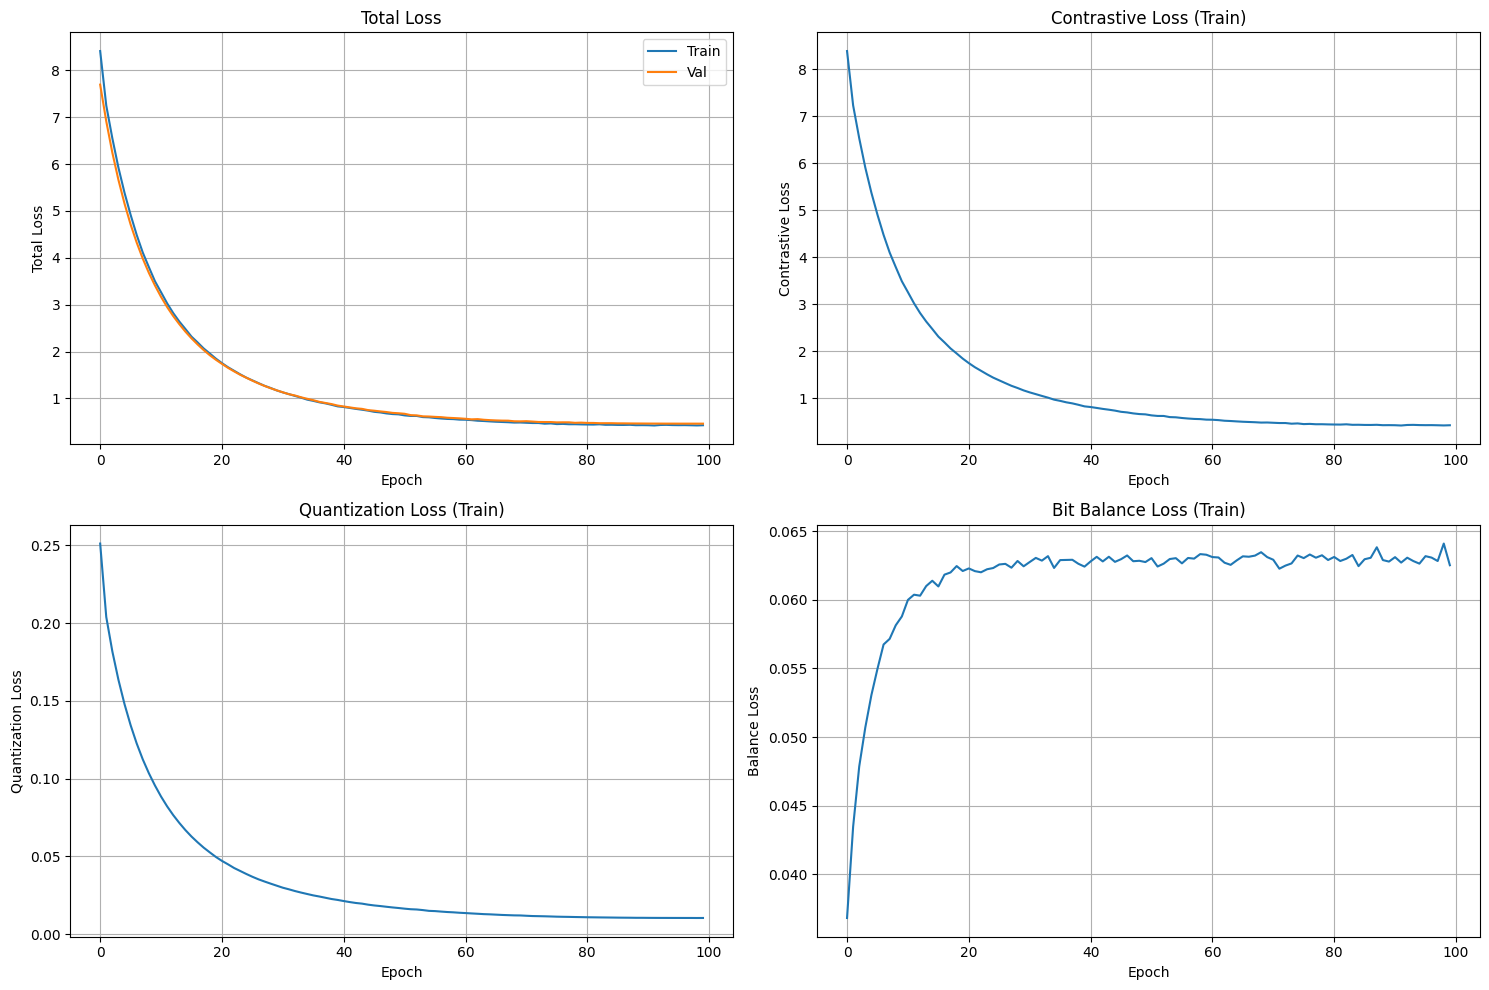

In [14]:
# ============================================================================
# PLOT TRAINING CURVES
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Total loss
axes[0, 0].plot(history['train_loss'], label='Train')
axes[0, 0].plot(history['val_loss'], label='Val')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Total Loss')
axes[0, 0].set_title('Total Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Contrastive loss
axes[0, 1].plot(history['train_contrastive'])
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Contrastive Loss')
axes[0, 1].set_title('Contrastive Loss (Train)')
axes[0, 1].grid(True)

# Quantization loss
axes[1, 0].plot(history['train_quantization'])
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Quantization Loss')
axes[1, 0].set_title('Quantization Loss (Train)')
axes[1, 0].grid(True)

# Balance loss
axes[1, 1].plot(history['train_balance'])
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Balance Loss')
axes[1, 1].set_title('Bit Balance Loss (Train)')
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'training_curves.png'), dpi=150)
print(f"\n✓ Training curves saved to: {CONFIG['output_dir']}/training_curves.png")
plt.show()

In [ ]:
# INFERENCE EXAMPLE


In [18]:
# ============================================================================
# MEMORY-EFFICIENT EVALUATION (COMPLETE REPLACEMENT)
# ============================================================================

from sklearn.metrics import average_precision_score
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
import numpy as np

def compute_hamming_distance(codes1, codes2):
    """
    Compute Hamming distance between binary codes
    codes1: [N1, K]
    codes2: [N2, K]
    returns: [N1, N2]
    """
    return (codes1.unsqueeze(1) != codes2.unsqueeze(0)).sum(dim=2).float()


def compute_map_batch(hash_codes, labels, top_k=100, batch_size=500):
    """
    Memory-efficient mAP computation using batching

    Args:
        hash_codes: Binary codes [N, K]
        labels: Class labels [N]
        top_k: Number of top retrievals
        batch_size: Process this many queries at once

    Returns:
        mAP score
    """
    n = hash_codes.size(0)
    device = hash_codes.device

    aps = []

    # Process queries in batches to save memory
    for i in tqdm(range(0, n, batch_size), desc='Computing mAP', leave=False):
        end = min(i + batch_size, n)
        batch_codes = hash_codes[i:end]
        batch_labels = labels[i:end]

        # Compute distances for this batch of queries against ALL database
        hamming_dist = compute_hamming_distance(batch_codes, hash_codes)

        # Ground truth: same label = relevant
        relevance = (batch_labels.unsqueeze(1) == labels.unsqueeze(0)).float()

        # Compute AP for each query in the batch
        for j in range(len(batch_codes)):
            query_idx = i + j
            dist = hamming_dist[j]
            rel = relevance[j]

            # Sort by distance (ascending)
            sorted_indices = torch.argsort(dist)

            # Remove self-match
            sorted_indices = sorted_indices[sorted_indices != query_idx][:top_k]

            # Get relevance of retrieved items
            retrieved_rel = rel[sorted_indices].cpu().numpy()

            # Compute average precision if there are relevant items
            if retrieved_rel.sum() > 0:
                try:
                    # Use negative distance as score (smaller distance = higher score)
                    ap = average_precision_score(
                        retrieved_rel,
                        -dist[sorted_indices].cpu().numpy()
                    )
                    aps.append(ap)
                except:
                    pass

    return np.mean(aps) if aps else 0.0


def evaluate_hashing(model, features, labels, device, top_k=100, sample_size=None):
    """
    Memory-efficient comprehensive evaluation

    Args:
        model: Deep hashing model
        features: Feature vectors [N, 512]
        labels: Class labels [N]
        device: torch device
        top_k: Top-k for mAP
        sample_size: If provided, subsample for faster evaluation

    Returns:
        Dictionary of evaluation metrics and hash codes
    """
    model.eval()

    # Subsample if requested
    if sample_size and len(features) > sample_size:
        print(f"\n⚠️ Subsampling {sample_size} samples for evaluation (out of {len(features)})")
        indices = np.random.choice(len(features), sample_size, replace=False)
        features = features[indices]
        labels = labels[indices]

    # Convert to tensors
    features_tensor = torch.from_numpy(features).float().to(device)
    labels_tensor = torch.from_numpy(labels).long().to(device)

    # Generate binary hash codes in batches
    print("\n📊 Generating hash codes...")
    all_hash_codes = []

    batch_size = 256
    with torch.no_grad():
        for i in tqdm(range(0, len(features_tensor), batch_size),
                     desc='Hashing', leave=False):
            batch = features_tensor[i:i+batch_size]
            batch_codes = model.get_binary_codes(batch)
            all_hash_codes.append(batch_codes)

    hash_codes = torch.cat(all_hash_codes, dim=0)

    print("\n" + "="*70)
    print("EVALUATION METRICS")
    print("="*70)

    # 1. Mean Average Precision (using batched computation)
    print("\n1. Computing Mean Average Precision (mAP)...")
    map_score = compute_map_batch(hash_codes, labels_tensor, top_k=top_k, batch_size=500)
    print(f"   mAP@{top_k}: {map_score:.4f}")

    # 2. Hamming distance distribution (sample for efficiency)
    print("\n2. Analyzing Hamming distance distribution...")

    sample_size_hamming = min(2000, len(hash_codes))
    sample_indices = torch.randperm(len(hash_codes))[:sample_size_hamming]
    sample_codes = hash_codes[sample_indices]
    sample_labels = labels_tensor[sample_indices]

    hamming_dist = compute_hamming_distance(sample_codes, sample_codes)
    similar_mask = (sample_labels.unsqueeze(1) == sample_labels.unsqueeze(0))

    similar_dist = hamming_dist[similar_mask].cpu().numpy()
    dissimilar_dist = hamming_dist[~similar_mask].cpu().numpy()

    print(f"   Similar pairs:")
    print(f"     Mean: {similar_dist.mean():.2f} bits")
    print(f"     Std: {similar_dist.std():.2f} bits")
    print(f"   Dissimilar pairs:")
    print(f"     Mean: {dissimilar_dist.mean():.2f} bits")
    print(f"     Std: {dissimilar_dist.std():.2f} bits")

    # 3. Collision probability
    print("\n3. Computing collision probability...")

    identical_similar = (hamming_dist[similar_mask] == 0).float().mean().item()
    identical_dissimilar = (hamming_dist[~similar_mask] == 0).float().mean().item()

    print(f"   Similar pairs (collision rate): {identical_similar:.4f}")
    print(f"   Dissimilar pairs (collision rate): {identical_dissimilar:.4f}")

    # 4. Bit statistics
    print("\n4. Analyzing bit statistics...")
    bit_means = hash_codes.float().mean(dim=0).cpu().numpy()
    bit_balance = np.abs(bit_means - 0.5).mean()

    print(f"   Bit balance (0 = perfect, 0.5 = worst): {bit_balance:.4f}")
    print(f"   Bits with >90% same value: {(np.abs(bit_means - 0.5) > 0.4).sum()} / {len(bit_means)}")

    print("\n" + "="*70)

    # Compile metrics
    metrics = {
        'map': float(map_score),
        'hamming_similar_mean': float(similar_dist.mean()),
        'hamming_similar_std': float(similar_dist.std()),
        'hamming_dissimilar_mean': float(dissimilar_dist.mean()),
        'hamming_dissimilar_std': float(dissimilar_dist.std()),
        'collision_similar': float(identical_similar),
        'collision_dissimilar': float(identical_dissimilar),
        'bit_balance': float(bit_balance),
        'num_samples': len(features),
        'top_k': top_k
    }

    return metrics, hash_codes


print("✓ Memory-efficient evaluation functions defined")


✓ Memory-efficient evaluation functions defined


In [19]:
# ============================================================================
# RUN EVALUATION (MEMORY-EFFICIENT)
# ============================================================================

print("\n" + "="*70)
print("EVALUATING TRAINED DEEP HASHING MODEL")
print("="*70)

# Load best model
checkpoint = torch.load(os.path.join(CONFIG['output_dir'], 'best_deephash_model.pt'))
hash_model.load_state_dict(checkpoint['model_state_dict'])
print(f"\n✓ Loaded best model from epoch {checkpoint['epoch']}")

# Get validation data
val_indices = val_dataset.indices
val_features = features[val_indices]
val_labels = labels[val_indices]

print(f"\n📊 Validation set: {len(val_features)} samples")

# For 3734 samples, no need to subsample - batch processing handles it
metrics, hash_codes = evaluate_hashing(
    hash_model,
    val_features,
    val_labels,
    device,
    top_k=CONFIG['top_k'],
    sample_size=None  # Use all 3734 samples
)

# Save metrics
metrics_path = os.path.join(CONFIG['output_dir'], 'evaluation_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"\n✅ Evaluation complete!")
print(f"✅ Metrics saved to: {metrics_path}")

# Print summary
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"mAP@{CONFIG['top_k']}: {metrics['map']:.4f}")
print(f"Hamming distance (similar): {metrics['hamming_similar_mean']:.2f} bits")
print(f"Hamming distance (dissimilar): {metrics['hamming_dissimilar_mean']:.2f} bits")
print(f"Separation: {metrics['hamming_dissimilar_mean'] - metrics['hamming_similar_mean']:.2f} bits")
print("="*70)



EVALUATING TRAINED DEEP HASHING MODEL

✓ Loaded best model from epoch 100

📊 Validation set: 3734 samples

📊 Generating hash codes...


Hashing:   0%|          | 0/15 [00:00<?, ?it/s]


EVALUATION METRICS

1. Computing Mean Average Precision (mAP)...


Computing mAP:   0%|          | 0/8 [00:00<?, ?it/s]

   mAP@100: 0.9770

2. Analyzing Hamming distance distribution...
   Similar pairs:
     Mean: 0.32 bits
     Std: 6.52 bits
   Dissimilar pairs:
     Mean: 142.79 bits
     Std: 13.78 bits

3. Computing collision probability...
   Similar pairs (collision rate): 0.9964
   Dissimilar pairs (collision rate): 0.0014

4. Analyzing bit statistics...
   Bit balance (0 = perfect, 0.5 = worst): 0.0974
   Bits with >90% same value: 0 / 256


✅ Evaluation complete!
✅ Metrics saved to: /content/drive/MyDrive/FYP/datasets/output_dir/evaluation_metrics.json

SUMMARY
mAP@100: 0.9770
Hamming distance (similar): 0.32 bits
Hamming distance (dissimilar): 142.79 bits
Separation: 142.47 bits



✓ Hamming distance plot saved to: /content/drive/MyDrive/FYP/datasets/output_dir/hamming_distance_distribution.png


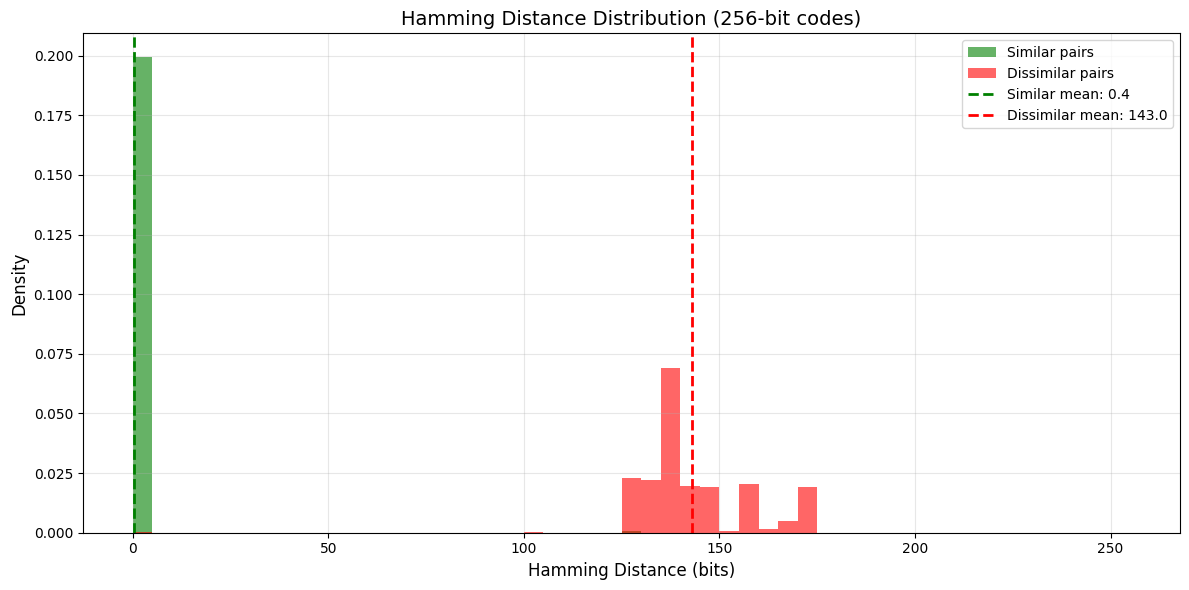

In [20]:
# ============================================================================
# VISUALIZE HAMMING DISTANCE DISTRIBUTION
# ============================================================================

# Sample for visualization
sample_size = min(2000, len(hash_codes))
sample_indices = torch.randperm(len(hash_codes))[:sample_size]
sample_codes = hash_codes[sample_indices]
sample_labels = torch.from_numpy(val_labels[sample_indices.cpu().numpy()]).to(device)

hamming_dist = compute_hamming_distance(sample_codes, sample_codes)
similar_mask = (sample_labels.unsqueeze(1) == sample_labels.unsqueeze(0))

similar_dist = hamming_dist[similar_mask].cpu().numpy()
dissimilar_dist = hamming_dist[~similar_mask].cpu().numpy()

# Plot histogram
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

bins = np.arange(0, CONFIG['hash_bits']+1, 5)
ax.hist(similar_dist, bins=bins, alpha=0.6, label='Similar pairs', color='green', density=True)
ax.hist(dissimilar_dist, bins=bins, alpha=0.6, label='Dissimilar pairs', color='red', density=True)

ax.axvline(similar_dist.mean(), color='green', linestyle='--', linewidth=2, label=f'Similar mean: {similar_dist.mean():.1f}')
ax.axvline(dissimilar_dist.mean(), color='red', linestyle='--', linewidth=2, label=f'Dissimilar mean: {dissimilar_dist.mean():.1f}')

ax.set_xlabel('Hamming Distance (bits)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Hamming Distance Distribution ({CONFIG["hash_bits"]}-bit codes)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'hamming_distance_distribution.png'), dpi=150)
print(f"\n✓ Hamming distance plot saved to: {CONFIG['output_dir']}/hamming_distance_distribution.png")
plt.show()

In [21]:
# ============================================================================
# SAVE PRODUCTION MODEL
# ============================================================================

print("\n" + "="*70)
print("SAVING PRODUCTION-READY MODEL")
print("="*70)

# Save complete model for deployment
production_model = {
    'hash_model': hash_model,
    'hash_model_state_dict': hash_model.state_dict(),
    'feature_extractor_path': CONFIG['feature_extractor_path'],
    'config': CONFIG,
    'metrics': metrics,
    'input_dim': CONFIG['input_dim'],
    'hash_bits': CONFIG['hash_bits'],
    'training_history': history
}

production_path = os.path.join(CONFIG['output_dir'], 'deephash_production.pt')
torch.save(production_model, production_path)

file_size = os.path.getsize(production_path) / 1024  # KB

print(f"\n✓ Production model saved to: {production_path}")
print(f"✓ File size: {file_size:.2f} KB")
print(f"\n📦 Model contains:")
print(f"  - Deep Hashing model (trained)")
print(f"  - Reference to feature extractor")
print(f"  - Configuration")
print(f"  - Evaluation metrics")
print(f"  - Training history")
print("="*70)


SAVING PRODUCTION-READY MODEL

✓ Production model saved to: /content/drive/MyDrive/FYP/datasets/output_dir/deephash_production.pt
✓ File size: 525.21 KB

📦 Model contains:
  - Deep Hashing model (trained)
  - Reference to feature extractor
  - Configuration
  - Evaluation metrics
  - Training history


In [23]:
# ============================================================================
# INFERENCE DEMO (PYTORCH 2.6+ COMPATIBLE)
# ============================================================================

print("\n" + "="*70)
print("INFERENCE DEMO")
print("="*70)

production_path = os.path.join(CONFIG['output_dir'], 'deephash_production.pt')

# Load production model (weights_only=False for PyTorch 2.6+)
loaded_model = torch.load(production_path, weights_only=False)
inference_hash_model = loaded_model['hash_model']
inference_hash_model.eval()
inference_hash_model = inference_hash_model.to(device)

print(f"\n✓ Loaded production model from: {production_path}")
print(f"✓ Model configuration:")
print(f"  - Input dim: {loaded_model['config']['input_dim']}")
print(f"  - Hash bits: {loaded_model['config']['hash_bits']}")
print(f"  - mAP: {loaded_model['metrics']['map']:.4f}")

# Demo: Generate hash codes from validation set
print("\n" + "="*70)
print("DEMO: Hash Code Generation")
print("="*70)

# Take a small sample for demo
demo_size = 10
demo_indices = np.random.choice(len(val_features), demo_size, replace=False)
demo_features = val_features[demo_indices]
demo_labels = val_labels[demo_indices]

# Convert to tensors
demo_features_tensor = torch.from_numpy(demo_features).float().to(device)
demo_labels_tensor = torch.from_numpy(demo_labels).long()

# Generate hash codes
with torch.no_grad():
    demo_hash_codes = inference_hash_model.get_binary_codes(demo_features_tensor)

print(f"\n✓ Generated hash codes for {demo_size} samples")
print(f"\nSample hash codes:")
print("-" * 70)

for i in range(min(5, demo_size)):
    hash_code = demo_hash_codes[i].cpu().numpy()
    label = demo_labels_tensor[i].item()

    # Convert to binary string (show first 64 bits for readability)
    hash_str = ''.join(map(str, hash_code[:64].tolist()))

    print(f"Sample {i+1} (Label {label}):")
    print(f"  First 64 bits: {hash_str}...")
    print(f"  Total 1s: {hash_code.sum()}/{len(hash_code)}")
    print()

# Demo: Compute pairwise Hamming distances
print("="*70)
print("DEMO: Similarity Search")
print("="*70)

# Pick one query
query_idx = 0
query_hash = demo_hash_codes[query_idx:query_idx+1]
query_label = demo_labels_tensor[query_idx].item()

print(f"\nQuery image (Label {query_label})")
print("-" * 70)

# Compute Hamming distances to all other samples
hamming_distances = (query_hash != demo_hash_codes).sum(dim=1).cpu().numpy()

# Sort by distance
sorted_indices = np.argsort(hamming_distances)[1:]  # Exclude self

print(f"\nTop 5 most similar images:")
print(f"{'Rank':<6} {'Label':<8} {'Hamming Distance':<18} {'Same Class':<12}")
print("-" * 70)

for rank, idx in enumerate(sorted_indices[:5], 1):
    dist = hamming_distances[idx]
    label = demo_labels_tensor[idx].item()
    same_class = "✓ Yes" if label == query_label else "✗ No"
    print(f"{rank:<6} {label:<8} {dist:<18.0f} {same_class:<12}")

print("\n" + "="*70)

# Demo: Storage efficiency
print("\nSTORAGE EFFICIENCY")
print("="*70)

original_size = demo_features.nbytes
hash_size = demo_hash_codes.cpu().numpy().nbytes
compression_ratio = original_size / hash_size

print(f"\nOriginal features (512-D float32):")
print(f"  - Size: {original_size:,} bytes ({original_size/1024:.2f} KB)")
print(f"  - Per image: {original_size/demo_size:,} bytes")

print(f"\nHash codes (256-bit binary):")
print(f"  - Size: {hash_size:,} bytes ({hash_size/1024:.2f} KB)")
print(f"  - Per image: {hash_size/demo_size:,} bytes")

print(f"\nCompression ratio: {compression_ratio:.1f}x smaller!")

print("\n" + "="*70)
print("✅ INFERENCE DEMO COMPLETE")
print("="*70)



INFERENCE DEMO

✓ Loaded production model from: /content/drive/MyDrive/FYP/datasets/output_dir/deephash_production.pt
✓ Model configuration:
  - Input dim: 512
  - Hash bits: 256
  - mAP: 0.9770

DEMO: Hash Code Generation

✓ Generated hash codes for 10 samples

Sample hash codes:
----------------------------------------------------------------------
Sample 1 (Label 5):
  First 64 bits: 0101101100100010111110101010011111010100001100001101111010011000...
  Total 1s: 128/256

Sample 2 (Label 3):
  First 64 bits: 0000100110000010110101111110101011100101100010100010011000100111...
  Total 1s: 134/256

Sample 3 (Label 5):
  First 64 bits: 0101101100100010111110101010011111010100001100001101111010011000...
  Total 1s: 128/256

Sample 4 (Label 0):
  First 64 bits: 1110001001011100000000000100111011010010010100111011000101110111...
  Total 1s: 132/256

Sample 5 (Label 4):
  First 64 bits: 1001101110100101110100100110100000101110000011010011111110100111...
  Total 1s: 127/256

DEMO: Similarity

In [24]:
# ============================================================================
# INFERENCE FUNCTION FOR DEPLOYMENT
# ============================================================================

def hash_image(image_path, feature_extractor, hash_model, transform, device):
    """
    Complete pipeline: Image → 512-D features → 256-bit binary hash

    Args:
        image_path: Path to image file
        feature_extractor: Pre-trained ConvNeXt-V2 model
        hash_model: Trained deep hashing model
        transform: Image preprocessing transform
        device: torch device

    Returns:
        Binary hash code as numpy array [256] of {0, 1}
    """
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Extract 512-D features
    with torch.no_grad():
        features = feature_extractor(image_tensor, return_features=True)

        # Generate binary hash code
        hash_code = hash_model.get_binary_codes(features)

    return hash_code.cpu().numpy()[0]


def compute_similarity(hash1, hash2):
    """
    Compute similarity between two hash codes

    Args:
        hash1, hash2: Binary hash codes [K]

    Returns:
        Hamming distance (lower = more similar)
    """
    return np.sum(hash1 != hash2)


print("✓ Inference functions defined")
print("\n📚 Usage example:")
print("  hash_code = hash_image('image.jpg', feature_extractor, hash_model, transform, device)")
print("  distance = compute_similarity(hash1, hash2)")

✓ Inference functions defined

📚 Usage example:
  hash_code = hash_image('image.jpg', feature_extractor, hash_model, transform, device)
  distance = compute_similarity(hash1, hash2)


In [25]:
# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*70)
print("DEEP HASHING TRAINING SUMMARY")
print("="*70)

print(f"\n📊 Dataset:")
print(f"  Total images: {len(features)}")
print(f"  Train samples: {len(train_dataset)}")
print(f"  Val samples: {len(val_dataset)}")

print(f"\n🏗️ Architecture:")
print(f"  Input: 512-D features (ConvNeXt-V2)")
print(f"  Output: {CONFIG['hash_bits']}-bit binary codes")
print(f"  Trainable params: {sum(p.numel() for p in hash_model.parameters()):,}")

print(f"\n📈 Training:")
print(f"  Epochs trained: {len(history['train_loss'])}")
print(f"  Best val loss: {best_val_loss:.4f}")
print(f"  Training time: {elapsed/60:.2f} minutes")

print(f"\n🎯 Evaluation Metrics:")
print(f"  mAP@{CONFIG['top_k']}: {metrics['map']:.4f}")
print(f"  Hamming distance (similar): {metrics['hamming_similar_mean']:.2f} bits")
print(f"  Hamming distance (dissimilar): {metrics['hamming_dissimilar_mean']:.2f} bits")
print(f"  Collision rate (similar): {metrics['collision_similar']:.4f}")
print(f"  Collision rate (dissimilar): {metrics['collision_dissimilar']:.4f}")
print(f"  Bit balance: {metrics['bit_balance']:.4f}")

print(f"\n💾 Saved Files:")
print(f"  Production model: deephash_production.pt")
print(f"  Best checkpoint: best_deephash_model.pt")
print(f"  Features cache: extracted_features.npz")
print(f"  Training history: training_history.json")
print(f"  Evaluation metrics: evaluation_metrics.json")
print(f"  Visualizations: training_curves.png, hamming_distance_distribution.png")

print(f"\n📁 Output directory: {CONFIG['output_dir']}")

print("\n" + "="*70)
print("✅ DEEP HASHING PIPELINE COMPLETE!")
print("="*70)

print("\n🚀 Next steps:")
print("  1. Use deephash_production.pt for deployment")
print("  2. Generate hash codes for your entire image database")
print("  3. Build fast retrieval system using Hamming distance")
print("  4. Index codes for sub-linear search (e.g., hash tables)")


DEEP HASHING TRAINING SUMMARY

📊 Dataset:
  Total images: 18669
  Train samples: 14935
  Val samples: 3734

🏗️ Architecture:
  Input: 512-D features (ConvNeXt-V2)
  Output: 256-bit binary codes
  Trainable params: 131,840

📈 Training:
  Epochs trained: 100
  Best val loss: 0.4631
  Training time: 1.38 minutes

🎯 Evaluation Metrics:
  mAP@100: 0.9770
  Hamming distance (similar): 0.32 bits
  Hamming distance (dissimilar): 142.79 bits
  Collision rate (similar): 0.9964
  Collision rate (dissimilar): 0.0014
  Bit balance: 0.0974

💾 Saved Files:
  Production model: deephash_production.pt
  Best checkpoint: best_deephash_model.pt
  Features cache: extracted_features.npz
  Training history: training_history.json
  Evaluation metrics: evaluation_metrics.json
  Visualizations: training_curves.png, hamming_distance_distribution.png

📁 Output directory: /content/drive/MyDrive/FYP/datasets/output_dir

✅ DEEP HASHING PIPELINE COMPLETE!

🚀 Next steps:
  1. Use deephash_production.pt for deployment